# 01 - EDA del dataset ASL Alphabet

Este notebook explora el dataset ya preprocesado en `data/asl_alphabet_v1/processed`.

Contenido:
1. Setup e imports
2. Generar (o cargar) el reporte EDA
3. Balance de clases
4. Distribucion de tamanos y aspect ratio
5. Color e histograma de intensidad
6. Muestras visuales por clase
7. Conclusiones para modelado

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import random

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from src.eda.image_stats import collect_split_files, run_eda

DATA_ROOT = PROJECT_ROOT / "data" / "asl_alphabet_v1" / "processed"
REPORT_PATH = PROJECT_ROOT / "artifacts" / "eda" / "asl_alphabet_eda.json"
SAMPLE_PER_SPLIT = 900
SEED = 42

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)

PROJECT_ROOT: c:\Users\aleja\Documents\Comillas\2º Cuatri\Análisis de Datos no Estructurados\signlanguage-classifier
DATA_ROOT: c:\Users\aleja\Documents\Comillas\2º Cuatri\Análisis de Datos no Estructurados\signlanguage-classifier\data\asl_alphabet_v1\processed


## Generar (o cargar) el reporte EDA

In [2]:
if REPORT_PATH.exists():
    report = json.loads(REPORT_PATH.read_text(encoding="utf-8"))
    print("Loaded cached EDA report from", REPORT_PATH)
else:
    report = run_eda(
        data_root=DATA_ROOT,
        splits=["train", "val", "test"],
        sample_per_split=SAMPLE_PER_SPLIT,
        seed=SEED,
    )
    REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
    REPORT_PATH.write_text(json.dumps(report, indent=2), encoding="utf-8")
    print("Saved fresh EDA report to", REPORT_PATH)

overall = report["overall"]
print("Total images:", report["total_images"])
print("Sampled images:", report["sampled_images"])
print("Num classes:", overall["num_classes"])
print("Imbalance ratio max/min:", round(overall["class_balance"]["imbalance_ratio_max_over_min"], 3))

Loaded cached EDA report from c:\Users\aleja\Documents\Comillas\2º Cuatri\Análisis de Datos no Estructurados\signlanguage-classifier\artifacts\eda\asl_alphabet_eda.json
Total images: 223102
Sampled images: 9000
Num classes: 29
Imbalance ratio max/min: 2.791


## Balance de clases

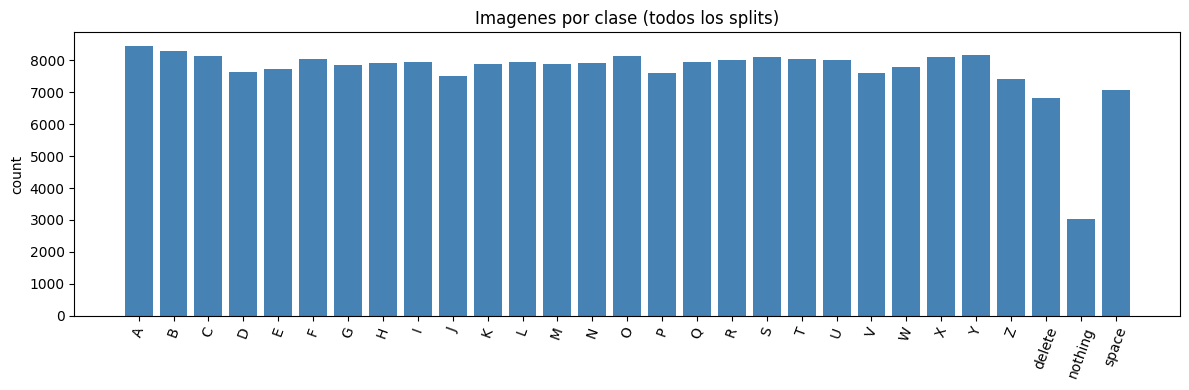

In [3]:
class_totals = overall["class_totals"]
labels = list(class_totals.keys())
counts = list(class_totals.values())

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(labels, counts, color="steelblue")
ax.set_title("Imagenes por clase (todos los splits)")
ax.set_ylabel("count")
ax.tick_params(axis="x", rotation=70)
plt.tight_layout()
plt.show()

## Distribucion de tamanos y aspect ratio

In [4]:
print("Width:", overall["width_distribution"])
print("Height:", overall["height_distribution"])
print("Aspect ratio:", overall["aspect_ratio_distribution"])
print("Image modes:", overall["mode_counts"])
print("Image formats:", overall["format_counts"])

Width: {'min': 200.0, 'p25': 200.0, 'median': 200.0, 'p75': 200.0, 'max': 1920.0, 'mean': 239.25333333333333, 'std': 160.4254698536918}
Height: {'min': 200.0, 'p25': 200.0, 'median': 200.0, 'p75': 200.0, 'max': 1920.0, 'mean': 234.61333333333334, 'std': 149.69882891251282}
Aspect ratio: {'min': 1.0, 'p25': 1.0, 'median': 1.0, 'p75': 1.0, 'max': 1.7777777777777777, 'mean': 1.009407407407407, 'std': 0.057251688445878836}
Image modes: {'RGB': 9000}
Image formats: {'jpeg': 9000}


## Color e histograma de intensidad

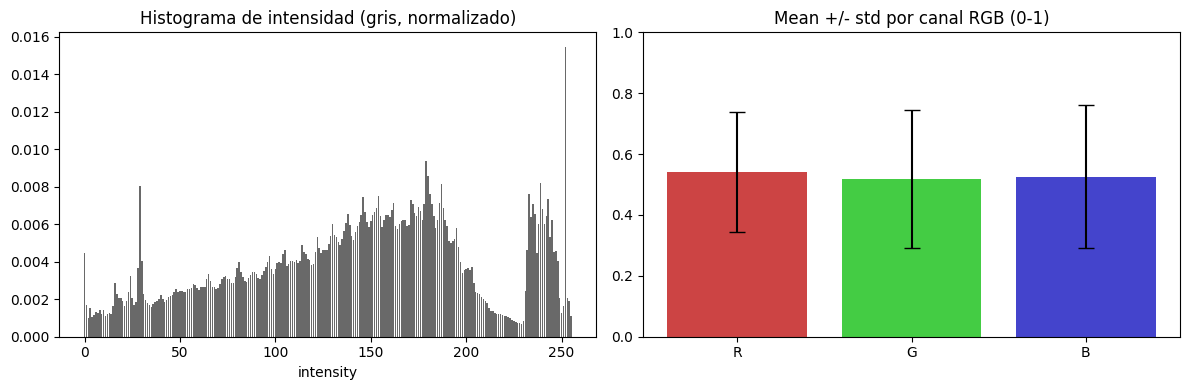

In [5]:
gray_hist = np.array(overall["grayscale_histogram"], dtype=np.float64)
gray_hist = gray_hist / gray_hist.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(np.arange(256), gray_hist, color="dimgray")
axes[0].set_title("Histograma de intensidad (gris, normalizado)")
axes[0].set_xlabel("intensity")

means = overall["rgb_channel_mean"]
stds = overall["rgb_channel_std"]
channels = ["R", "G", "B"]
mean_values = [means[c.lower()] for c in channels]
std_values = [stds[c.lower()] for c in channels]
axes[1].bar(channels, mean_values, yerr=std_values, color=["#c44", "#4c4", "#44c"], capsize=6)
axes[1].set_ylim(0, 1)
axes[1].set_title("Mean +/- std por canal RGB (0-1)")
plt.tight_layout()
plt.show()

## Muestras visuales por clase

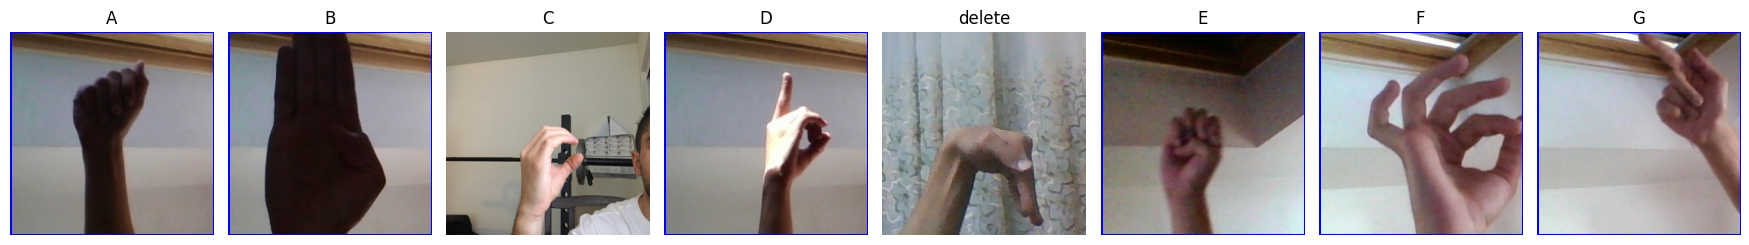

In [ ]:
rng = random.Random(SEED)
train_files = collect_split_files(DATA_ROOT / "train")
sample_classes = list(train_files.keys())[:8]

fig, axes = plt.subplots(1, len(sample_classes), figsize=(2.2 * len(sample_classes), 2.6))
for ax, label in zip(axes, sample_classes):
    paths = train_files[label]
    if not paths:
        ax.axis("off")
        continue
    ax.imshow(Image.open(rng.choice(paths)).convert("RGB"))
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Conclusiones para modelado

- Imagen tipica 200x200, mantenerla o subirla a 224x224 para backbones ImageNet.
- Desbalance moderado (`nothing` la mas baja). Considerar `class_weight='balanced'` y reportar F1 macro.
- Color con std ~0.20-0.23 por canal: las normalizaciones ImageNet siguen siendo razonables para fine-tuning.
- Hay outliers de tamanio (hasta 1920 px). El pipeline ya hace resize uniforme, pero conviene auditar esa minoria.